### [ 히스토그램과 평탄화 ] <hr>

- 픽셀값이 집중된 부분도 있고 흩어져 있는 부분들도 존재 => 정규화 사용 시 효과가 떨어짐
- 개선 방안 => 픽셀 빈도가 전체에 차지하는 비중 기반으로 변환하는 기법 => 평탄화
- 조건
    * 반드시 GrayScale 즉, 1채널만 가능 
    * 컬러이미지 => 그레이스케일이미지로 변환,  HSV/YUV로 변환 후 밝기 채널 즉, V/Y채널 사용

In [37]:
## ===================================
## 모듈 로딩
## ===================================
import cv2
import sys
sys.path.append(r'D:\KDT\VS_KDT_14\[7]_CV')
from cv_utils import printPlots, printPlotImage
import numpy as np

In [38]:
## ===================================
## 데이터 준비
## ===================================
IMG_FILE = '../Data/Images/yate.jpg' 

In [39]:
## ===================================
## 데이터 로딩 및 기본 정보 출력
## ===================================
grayNP  = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
colorNP = cv2.imread(IMG_FILE)

print(f'[grayNP]  => 형태 : {grayNP.shape},  차원 : {grayNP.ndim}D')
print(f'[colorNP] => 형태 : {colorNP.shape}, 차원 : {colorNP.ndim}D')

[grayNP]  => 형태 : (480, 640),  차원 : 2D
[colorNP] => 형태 : (480, 640, 3), 차원 : 3D


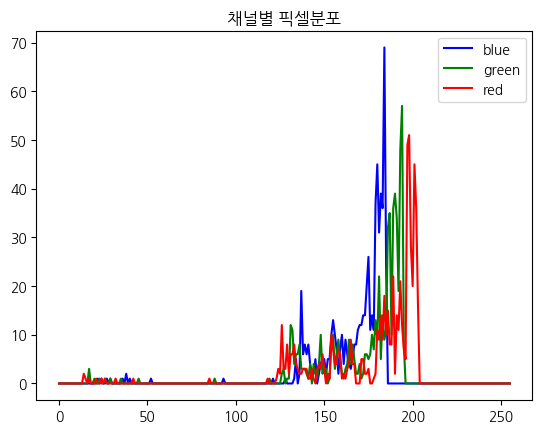

In [40]:
## ===================================
## 픽셀 분포 파악
## ===================================
import matplotlib.pyplot as plt 

bgrNPs = cv2.split(colorNP)
labels = ['blue','green', 'red']

for channelNP, label_ in zip(bgrNPs, labels):
    channelHist = cv2.calcHist(channelNP, [0], None, [256], [0, 256])
    plt.plot(channelHist, label=label_, c=label_)

plt.title("채널별 픽셀분포")
plt.legend()
plt.show()



[ 평탄화 ]<hr>

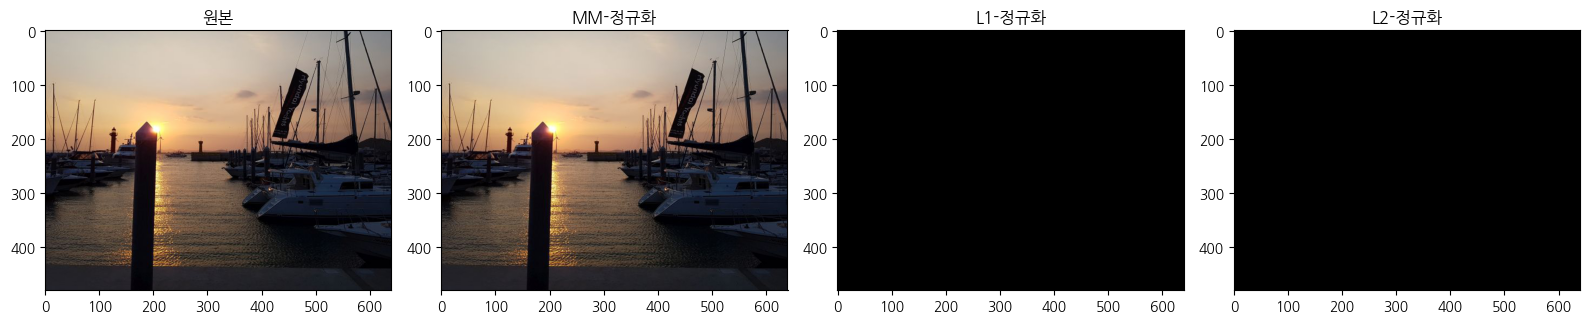

In [ ]:
## =============================================
## 단순 정규화 - 3가지
## =============================================
rgbNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2RGB)

normNPs = [cv2.normalize(rgbNP, None, 0, 255, norm_type) for norm_type in  [cv2.NORM_MINMAX, cv2.NORM_L1, cv2.NORM_L2]]

## 시각화 : 원본이미지, blue픽셀분포, green픽셀분포, red 픽셀 분포
titles_ = ['원본', 'MM-정규화', 'L1-정규화', 'L2-정규화']
plots_, images_ = [] , [rgbNP] + normNPs
cmap_   = [None]

printPlotImage(1, 4, titles_, plots_, images_, cmap_)

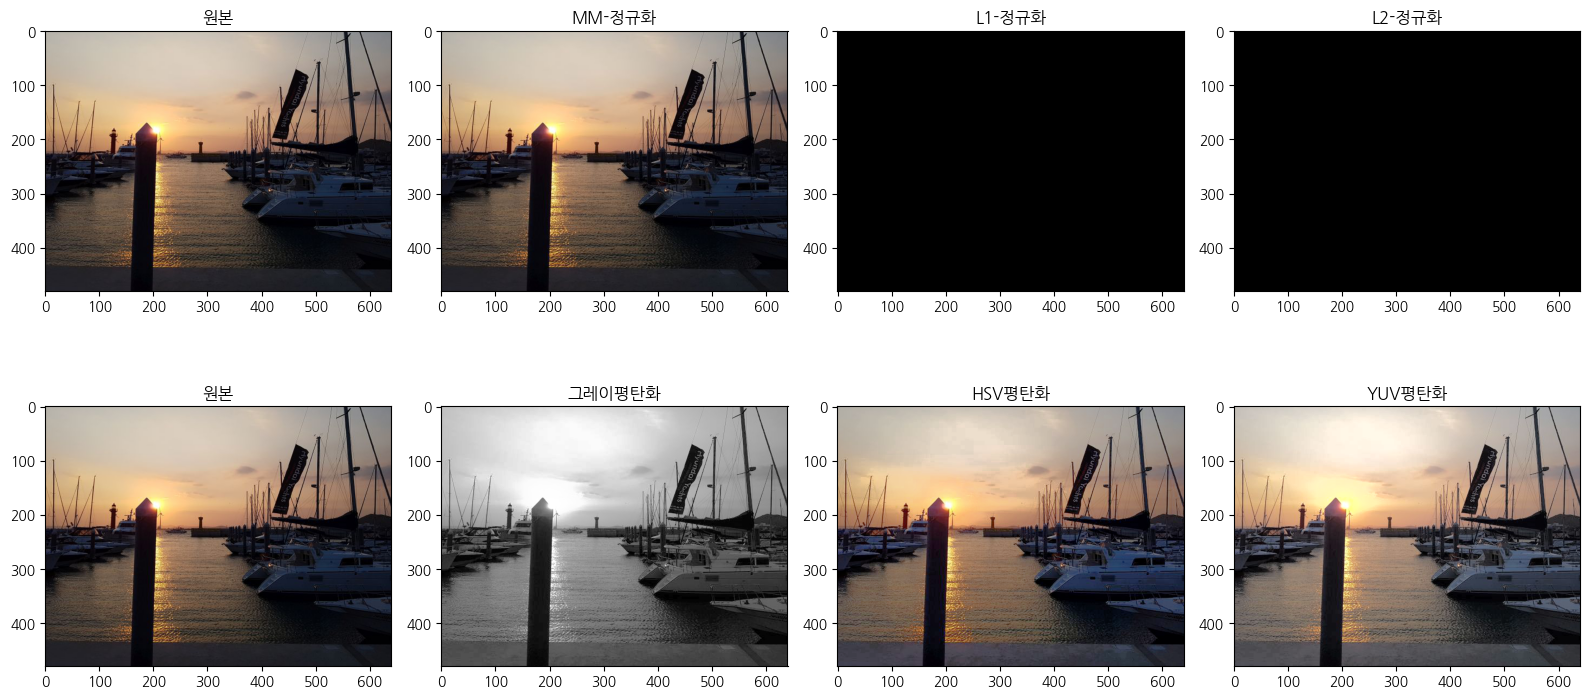

In [ ]:
## =============================================
## 원본 | 단순정규화 | 그레이스케일 | HSV | YUV 평탄화 결과 시각화 
## =============================================
rgbNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2RGB)

## 단순 정규화 3가지
normNPs = [cv2.normalize(rgbNP, None, 0, 255, norm_type) for norm_type in  [cv2.NORM_MINMAX, cv2.NORM_L1, cv2.NORM_L2]]

## 평탄화 3가지
## [1] 그레이스케일
grayNP = cv2.equalizeHist(grayNP)

## [2] HSV
hsvNP  = cv2.cvtColor(colorNP, cv2.COLOR_BGR2HSV)
hsvNP[:, :, 2] = cv2.equalizeHist(hsvNP[:, :, 2])

## [3] YUV
yuvNP = cv2.cvtColor(colorNP, cv2.COLOR_BGR2YUV)
yuvNP[:, :, 0] = cv2.equalizeHist(yuvNP[:, :, 0])

## 평탄화 후 컬러스페이스 변환
equalNPs = [ grayNP, hsvNP, yuvNP] 
flags    = [ cv2.COLOR_GRAY2RGB, cv2.COLOR_HSV2RGB, cv2.COLOR_YUV2RGB ]
equalNPs = [ cv2.cvtColor(imgNP, flag) for imgNP, flag in zip(equalNPs, flags) ]

## 시각화 : 원본이미지, blue픽셀분포, green픽셀분포, red 픽셀 분포
titles_ = ['원본', 'MM-정규화', 'L1-정규화', 'L2-정규화', '원본', '그레이평탄화', 'HSV평탄화', 'YUV평탄화']
plots_, images_ = [] , [rgbNP] + normNPs + [rgbNP] + equalNPs
cmap_   = [None]

printPlotImage(2, 4, titles_, plots_, images_, cmap_)